# Wayfair E-commerce Sales Review (2024–2025)

**Purpose:** audit the raw exports, define revenue consistently, explain the year-over-year sales story, and turn it into practical priorities for next year.

This notebook keeps each project stage in its own section. It begins with data-quality checks **before** analysis, records all cleaning decisions, then compares completed-order merchandise revenue across 2024 and 2025. Returned and canceled orders are excluded from net revenue and separately measured as operational outcomes.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path("datasets")
if not DATA_DIR.exists():
    DATA_DIR = Path.cwd() / "datasets"

customers_raw = pd.read_csv(DATA_DIR / "customers.csv")
orders_raw = pd.read_csv(DATA_DIR / "orders.csv")
order_items_raw = pd.read_csv(DATA_DIR / "order_items.csv")
products_raw = pd.read_csv(DATA_DIR / "products.csv")

raw_tables = {
    "customers": customers_raw,
    "orders": orders_raw,
    "order_items": order_items_raw,
    "products": products_raw,
}

profile = pd.DataFrame({
    name: {
        "rows": len(df),
        "columns": len(df.columns),
        "exact_duplicate_rows": int(df.duplicated().sum()),
        "columns_with_missing_values": int(df.isna().any().sum()),
        "missing_cells": int(df.isna().sum().sum()),
    }
    for name, df in raw_tables.items()
}).T

print("RAW EXPORT PROFILE")
display(profile)
print("\nRaw category labels:", sorted(products_raw["category"].dropna().astype(str).unique()))
print("Raw order statuses:", sorted(orders_raw["status"].dropna().astype(str).unique()))
print("Raw payment methods:", sorted(orders_raw["payment_method"].dropna().astype(str).unique()))
print("\nMissing values by table/column:")
for name, df in raw_tables.items():
    missing = df.isna().sum()
    missing = missing[missing.gt(0)]
    print(f"{name}: {missing.to_dict() if not missing.empty else 'none'}")

print("\nKEY / RELATIONSHIP CHECKS")
print("Duplicate customer IDs:", int(customers_raw["customer_id"].duplicated().sum()))
print("Duplicate order IDs:", int(orders_raw["order_id"].duplicated().sum()))
print("Duplicate product IDs:", int(products_raw["product_id"].duplicated().sum()))
print("Duplicate order-item keys (order_id, product_id):", int(order_items_raw.duplicated(["order_id", "product_id"]).sum()))
print("Order items with unknown order IDs:", int((~order_items_raw["order_id"].isin(orders_raw["order_id"])).sum()))
print("Order items with unknown product IDs:", int((~order_items_raw["product_id"].isin(products_raw["product_id"])).sum()))
print("Orders with unknown customer IDs:", int((~orders_raw["customer_id"].isin(customers_raw["customer_id"])).sum()))


RAW EXPORT PROFILE


,rows,columns,exact_duplicate_rows,columns_with_missing_values,missing_cells
customers,3600,4,0,0,0
orders,9245,7,38,1,7834
order_items,15608,5,0,1,199
products,90,5,0,0,0



Raw category labels: [' Bedding', ' Kitchen', ' Outdoor', 'BEDDING', 'Bath', 'Bedding', 'Decor', 'FURNITURE', 'Furniture', 'Furniture ', 'KITCHEN', 'Kitchen', 'Kitchen ', 'LIGHTING', 'Lighting', 'OUTDOOR', 'Outdoor', 'Storage', 'Storage ', 'bath', 'bedding', 'decor', 'furniture', 'kitchen']
Raw order statuses: ['canceled', 'completed', 'returned']
Raw payment methods: ['apple_pay', 'credit_card', 'gift_card', 'paypal']

Missing values by table/column:
customers: none
orders: {'discount_code': 7834}
order_items: {'unit_price': 199}
products: none

KEY / RELATIONSHIP CHECKS
Duplicate customer IDs: 0
Duplicate order IDs: 38
Duplicate product IDs: 0
Duplicate order-item keys (order_id, product_id): 0
Order items with unknown order IDs: 0
Order items with unknown product IDs: 0
Orders with unknown customer IDs: 0


## 1. Raw-data audit and cleaning decisions

The first cell profiles all four exports, checks missingness and exact duplicates, and tests key / foreign-key integrity. The category field is expected to need normalization (the raw sample contains whitespace and inconsistent capitalization). Blank discount codes are treated as **no promotion code**, not as missing transaction data. Other missing values and any invalid measures are counted and handled below rather than silently imputed.

**Cleaning policy:** trim and standardize text labels; parse dates and numeric fields; remove exact duplicate rows; retain the first row for a duplicated entity key after exact duplicates are removed (and report the count); drop rows missing required IDs / dates / status or containing invalid numeric item measures; do not invent customer, product, or order attributes. Optional discount codes remain null. Unmatched records are reported and excluded from joined analysis. These decisions preserve auditable source rows and avoid fabricating sales.

In [2]:
# Work on copies; keep the raw exports intact for traceability.
customers = customers_raw.copy()
orders = orders_raw.copy()
order_items = order_items_raw.copy()
products = products_raw.copy()

row_audit = []
for name, df in raw_tables.items():
    row_audit.append({
        "table": name,
        "raw_rows": len(df),
        "exact_duplicates_removed": int(df.duplicated().sum()),
    })

# Remove exact repeats first, then normalize textual labels consistently.
customers = customers.drop_duplicates().copy()
orders = orders.drop_duplicates().copy()
order_items = order_items.drop_duplicates().copy()
products = products.drop_duplicates().copy()

for df in [customers, orders, order_items, products]:
    for column in df.columns:
        if pd.api.types.is_string_dtype(df[column]):
            df[column] = df[column].astype("string").str.strip()

orders["status"] = orders["status"].str.lower().str.replace(r"[ -]+", "_", regex=True)
orders["payment_method"] = orders["payment_method"].str.lower().str.replace(r"[ -]+", "_", regex=True)
orders["discount_code"] = orders["discount_code"].fillna("no_code").str.lower()
customers["acquisition_channel"] = customers["acquisition_channel"].str.lower().str.replace(r"[ -]+", "_", regex=True)
products["category"] = products["category"].str.title()

# Parse types and coerce malformed numeric text to missing so it can be audited.
orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")
customers["signup_date"] = pd.to_datetime(customers["signup_date"], errors="coerce")
for column in ["quantity", "unit_price", "discount_amount"]:
    order_items[column] = pd.to_numeric(order_items[column], errors="coerce")
for column in ["list_price", "unit_cost"]:
    products[column] = pd.to_numeric(products[column], errors="coerce")
orders["shipping_fee"] = pd.to_numeric(orders["shipping_fee"], errors="coerce")

# Record entity-key conflicts before resolving them by retaining the first source row.
entity_keys = {"customers": (customers, "customer_id"), "orders": (orders, "order_id"), "products": (products, "product_id")}
for name, (df, key) in entity_keys.items():
    row_audit["customers orders order_items products".split().index(name)]["duplicate_entity_keys"] = int(df[key].duplicated().sum())
    if df[key].duplicated().any():
        df.drop_duplicates(subset=[key], keep="first", inplace=True)

required_order_mask = orders[["order_id", "customer_id", "order_date", "status"]].notna().all(axis=1)
required_customer_mask = customers[["customer_id"]].notna().all(axis=1)
required_product_mask = products[["product_id", "product_name", "category"]].notna().all(axis=1)
valid_item_mask = (
    order_items[["order_id", "product_id", "quantity", "unit_price", "discount_amount"]].notna().all(axis=1)
    & order_items["quantity"].gt(0)
    & order_items["unit_price"].ge(0)
    & order_items["discount_amount"].ge(0)
    & (order_items["discount_amount"] <= order_items["quantity"] * order_items["unit_price"])
)
invalid_item_order_ids = set(order_items.loc[~valid_item_mask, "order_id"].dropna().unique())
source_item_order_ids = set(order_items["order_id"].dropna().unique())

cleaning_exclusions = {
    "orders_missing_required_fields": int((~required_order_mask).sum()),
    "customers_missing_id": int((~required_customer_mask).sum()),
    "products_missing_required_fields": int((~required_product_mask).sum()),
    "order_items_invalid_or_missing_required_values": int((~valid_item_mask).sum()),
}
orders = orders.loc[required_order_mask].copy()
customers = customers.loc[required_customer_mask].copy()
products = products.loc[required_product_mask].copy()
order_items = order_items.loc[valid_item_mask].copy()

# Exclude dangling foreign keys; count each affected record before filtering.
cleaning_exclusions["orders_with_unknown_customers"] = int((~orders["customer_id"].isin(customers["customer_id"])).sum())
cleaning_exclusions["items_with_unknown_orders"] = int((~order_items["order_id"].isin(orders["order_id"])).sum())
cleaning_exclusions["items_with_unknown_products"] = int((~order_items["product_id"].isin(products["product_id"])).sum())
orders = orders[orders["customer_id"].isin(customers["customer_id"])].copy()
order_items = order_items[order_items["order_id"].isin(orders["order_id"]) & order_items["product_id"].isin(products["product_id"])].copy()
orders_without_source_items = set(orders["order_id"]) - source_item_order_ids
incomplete_order_ids = (invalid_item_order_ids | orders_without_source_items).intersection(set(orders["order_id"]))
cleaning_exclusions["orders_with_incomplete_item_detail"] = len(incomplete_order_ids)

print("CLEANING AUDIT")
display(pd.DataFrame(row_audit).fillna(0))
print("\nExcluded-record counts:")
display(pd.Series(cleaning_exclusions, name="records"))
print("\nCanonical product categories:", sorted(products["category"].dropna().unique()))
print("Canonical order statuses:", sorted(orders["status"].dropna().unique()))
print("Remaining missing values (by table):")
for name, df in {"customers": customers, "orders": orders, "order_items": order_items, "products": products}.items():
    print(f"{name}: {df.isna().sum()[df.isna().sum().gt(0)].to_dict() or 'none'}")


CLEANING AUDIT


,table,raw_rows,exact_duplicates_removed,duplicate_entity_keys
0,customers,3600,0,0.0
1,orders,9245,38,0.0
2,order_items,15608,0,0.0
3,products,90,0,0.0



Excluded-record counts:


orders_missing_required_fields                      0
customers_missing_id                                0
products_missing_required_fields                    0
order_items_invalid_or_missing_required_values    199
orders_with_unknown_customers                       0
items_with_unknown_orders                           0
items_with_unknown_products                         0
orders_with_incomplete_item_detail                197
Name: records, dtype: int64


Canonical product categories: ['Bath', 'Bedding', 'Decor', 'Furniture', 'Kitchen', 'Lighting', 'Outdoor', 'Storage']
Canonical order statuses: ['canceled', 'completed', 'returned']
Remaining missing values (by table):
customers: none
orders: none
order_items: none
products: none


## 2. Revenue definition and order outcomes

**Revenue metric:** for each order line, net merchandise revenue is `quantity × unit_price − discount_amount`; order revenue is the sum of its line values. Annual/monthly sales include only 2024–2025 orders with normalized status `completed` and fully observed, valid item detail. Orders with any invalid/missing item line—or no source item rows—are excluded entirely from revenue and AOV rather than counted as partial sales; their count is shown in the cleaning audit. Returned, canceled, and other non-completed orders are excluded from sales revenue but retained in the overall status/outcome rates. Shipping is excluded because this review measures merchandise sales and has no tax/refund ledger to reconcile. This is discounted completed-order merchandise value, **not** accounting net revenue after refunds, shipping, or tax.

Order AOV is included merchandise revenue divided by included completed orders. Category AOV uses category revenue divided by included completed orders containing at least one item in that category. Category return/cancellation rates use only orders with complete valid item detail and containing that category as the denominator (orders can appear in multiple categories).

In [3]:
order_lines = order_items.merge(
    products[["product_id", "product_name", "category", "unit_cost"]],
    on="product_id",
    how="left",
    validate="many_to_one",
).merge(
    orders[["order_id", "customer_id", "order_date", "status", "shipping_fee"]],
    on="order_id",
    how="left",
    validate="many_to_one",
)
order_lines["gross_merchandise"] = order_lines["quantity"] * order_lines["unit_price"]
order_lines["net_merchandise_revenue"] = order_lines["gross_merchandise"] - order_lines["discount_amount"]
order_lines["year"] = order_lines["order_date"].dt.year
order_lines["month"] = order_lines["order_date"].dt.month
order_lines["month_name"] = order_lines["order_date"].dt.strftime("%b")

analysis_orders = orders.loc[orders["order_date"].dt.year.isin([2024, 2025])].copy()
analysis_orders["year"] = analysis_orders["order_date"].dt.year
analysis_orders["month"] = analysis_orders["order_date"].dt.month
order_revenue = order_lines.groupby("order_id", as_index=False)["net_merchandise_revenue"].sum()
analysis_orders = analysis_orders.merge(order_revenue, on="order_id", how="left", validate="one_to_one")
analysis_orders["net_merchandise_revenue"] = analysis_orders["net_merchandise_revenue"].fillna(0)

# Keep all valid order records for outcome rates, but exclude incomplete item detail from sales/AOV.
revenue_eligible_orders = analysis_orders.loc[~analysis_orders["order_id"].isin(incomplete_order_ids)].copy()
completed_orders = revenue_eligible_orders.loc[revenue_eligible_orders["status"].eq("completed")].copy()
completed_lines = order_lines.loc[
    order_lines["year"].isin([2024, 2025])
    & order_lines["status"].eq("completed")
    & ~order_lines["order_id"].isin(incomplete_order_ids)
].copy()

status_by_year = (
    analysis_orders.groupby(["year", "status"])["order_id"].nunique()
    .unstack(fill_value=0)
    .sort_index()
)
annual_sales = completed_orders.groupby("year").agg(
    revenue=("net_merchandise_revenue", "sum"),
    completed_orders=("order_id", "nunique"),
    average_order_value=("net_merchandise_revenue", "mean"),
)
annual_sales["revenue_yoy_pct"] = annual_sales["revenue"].pct_change() * 100
annual_sales["orders_yoy_pct"] = annual_sales["completed_orders"].pct_change() * 100
annual_sales["aov_yoy_pct"] = annual_sales["average_order_value"].pct_change() * 100

excluded_completed_orders = analysis_orders.loc[
    analysis_orders["status"].eq("completed") & analysis_orders["order_id"].isin(incomplete_order_ids), "order_id"
].nunique()
print("Order-status counts by year (all valid orders in the review period):")
display(status_by_year)
print("Annual completed-order merchandise sales (fully observed item detail only):")
display(annual_sales.style.format({"revenue": "${:,.0f}", "average_order_value": "${:,.2f}", "revenue_yoy_pct": "{:+.1f}%", "orders_yoy_pct": "{:+.1f}%", "aov_yoy_pct": "{:+.1f}%"}))
print("Orders with incomplete item detail excluded from all revenue/category metrics:", len(incomplete_order_ids))
print("Completed orders excluded from revenue/AOV:", excluded_completed_orders)


Order-status counts by year (all valid orders in the review period):


status,canceled,completed,returned
year,,,
2024,160,3867,185
2025,184,4589,222


Annual completed-order merchandise sales (fully observed item detail only):


,revenue,completed_orders,average_order_value,revenue_yoy_pct,orders_yoy_pct,aov_yoy_pct
year,,,,,,
2024,"$831,807",3798,$219.01,+nan%,+nan%,+nan%
2025,"$1,001,536",4484,$223.36,+20.4%,+18.1%,+2.0%


Orders with incomplete item detail excluded from all revenue/category metrics: 197
Completed orders excluded from revenue/AOV: 174


## 3. Monthly sales trend and seasonality

Compare like-for-like calendar months, report each month’s 2025 vs 2024 change, and summarize quarterly shares to identify recurring peaks. A year-over-year percentage is left blank when the 2024 comparison month has no revenue.

In [4]:
monthly_sales = (
    completed_orders.groupby(["year", "month"])["net_merchandise_revenue"]
    .sum()
    .unstack("year")
    .reindex(range(1, 13))
)
monthly_sales.columns.name = None
monthly_sales = monthly_sales.rename(columns={2024: "2024", 2025: "2025"})
for year in ["2024", "2025"]:
    if year not in monthly_sales.columns:
        monthly_sales[year] = 0.0
monthly_sales["2025_vs_2024_change"] = monthly_sales["2025"] - monthly_sales["2024"]
monthly_sales["2025_vs_2024_pct"] = np.where(
    monthly_sales["2024"].ne(0),
    monthly_sales["2025_vs_2024_change"] / monthly_sales["2024"] * 100,
    np.nan,
)
monthly_sales.index = pd.Index(pd.date_range("2024-01-01", periods=12, freq="MS").strftime("%b"), name="month")

quarterly_sales = completed_orders.assign(quarter=completed_orders["order_date"].dt.quarter).groupby(["year", "quarter"])["net_merchandise_revenue"].sum().unstack(fill_value=0)
quarterly_share = quarterly_sales.div(quarterly_sales.sum(axis=1), axis=0) * 100
month_seasonality = completed_orders.groupby("month")["net_merchandise_revenue"].agg(["mean", "sum", "count"]).reindex(range(1, 13))
month_seasonality.index = pd.Index(pd.date_range("2024-01-01", periods=12, freq="MS").strftime("%b"), name="month")

print("Monthly merchandise revenue comparison:")
display(monthly_sales.style.format({"2024": "${:,.0f}", "2025": "${:,.0f}", "2025_vs_2024_change": "${:+,.0f}", "2025_vs_2024_pct": "{:+.1f}%"}))
print("Quarterly share of each year's completed-order revenue (%):")
display(quarterly_share.style.format("{:.1f}%"))
print("Combined two-year monthly averages (useful for seasonality, not a forecast):")
display(month_seasonality.style.format({"mean": "${:,.2f}", "sum": "${:,.0f}", "count": "{:,.0f}"}))


Monthly merchandise revenue comparison:


,2024,2025,2025_vs_2024_change,2025_vs_2024_pct
month,,,,
Jan,"$54,029","$70,391","$+16,363",+30.3%
Feb,"$61,821","$67,745","$+5,924",+9.6%
Mar,"$70,590","$77,204","$+6,614",+9.4%
Apr,"$63,331","$77,526","$+14,194",+22.4%
May,"$71,559","$80,167","$+8,608",+12.0%
Jun,"$65,420","$90,176","$+24,756",+37.8%
Jul,"$75,275","$80,902","$+5,627",+7.5%
Aug,"$60,116","$87,471","$+27,355",+45.5%
Sep,"$59,989","$74,126","$+14,137",+23.6%


Quarterly share of each year's completed-order revenue (%):


quarter,1,2,3,4
year,,,,
2024,22.4%,24.1%,23.5%,30.0%
2025,21.5%,24.7%,24.2%,29.5%


Combined two-year monthly averages (useful for seasonality, not a forecast):


,mean,sum,count
month,,,
Jan,$224.58,"$124,420",554
Feb,$227.31,"$129,566",570
Mar,$232.38,"$147,794",636
Apr,$216.70,"$140,857",650
May,$229.89,"$151,726",660
Jun,$235.04,"$155,595",662
Jul,$241.39,"$156,177",647
Aug,$228.11,"$147,587",647
Sep,$228.87,"$134,115",586


## 4. Category drivers, best sellers, and category mix

Use net merchandise revenue for category ranking and show both order coverage and unit volume so a high-revenue item is not confused with the most frequently purchased one. Monthly category mix is calculated as each category’s share of that month’s completed-order merchandise revenue.

In [5]:
category_revenue = completed_lines.groupby("category")["net_merchandise_revenue"].sum().sort_values(ascending=False)
category_year_revenue = completed_lines.pivot_table(
    index="category", columns="year", values="net_merchandise_revenue", aggfunc="sum", fill_value=0
)
category_year_revenue["two_year_revenue"] = category_year_revenue.sum(axis=1)
category_year_revenue["share_of_sales_pct"] = category_year_revenue["two_year_revenue"] / category_year_revenue["two_year_revenue"].sum() * 100
category_year_revenue = category_year_revenue.sort_values("two_year_revenue", ascending=False)

product_performance = completed_lines.groupby(["product_id", "product_name", "category"], as_index=False).agg(
    units_sold=("quantity", "sum"),
    net_revenue=("net_merchandise_revenue", "sum"),
    orders=("order_id", "nunique"),
)
top_products_by_revenue = product_performance.sort_values("net_revenue", ascending=False).head(10)
top_products_by_units = product_performance.sort_values("units_sold", ascending=False).head(10)

monthly_category = completed_lines.pivot_table(
    index="month", columns="category", values="net_merchandise_revenue", aggfunc="sum", fill_value=0
).reindex(range(1, 13), fill_value=0)
monthly_category.index = pd.Index(pd.date_range("2024-01-01", periods=12, freq="MS").strftime("%b"), name="month")
monthly_category_mix_pct = monthly_category.div(monthly_category.sum(axis=1).replace(0, np.nan), axis=0) * 100

print("Two-year category revenue and share:")
display(category_year_revenue.style.format({"two_year_revenue": "${:,.0f}", "share_of_sales_pct": "{:.1f}%", 2024: "${:,.0f}", 2025: "${:,.0f}"}))
print("Top 10 products by net merchandise revenue:")
display(top_products_by_revenue.style.format({"net_revenue": "${:,.0f}"}))
print("Top 10 products by units sold:")
display(top_products_by_units.style.format({"net_revenue": "${:,.0f}"}))
print("Monthly category mix (% of monthly revenue):")
display(monthly_category_mix_pct.style.format("{:.1f}%"))


Two-year category revenue and share:


year,2024,2025,two_year_revenue,share_of_sales_pct
category,,,,
Furniture,"$139,914","$174,385","$314,299",17.1%
Kitchen,"$121,067","$151,339","$272,406",14.9%
Decor,"$124,650","$146,403","$271,053",14.8%
Bedding,"$121,130","$138,559","$259,689",14.2%
Outdoor,"$115,277","$124,995","$240,272",13.1%
Lighting,"$104,259","$128,384","$232,643",12.7%
Storage,"$56,237","$79,889","$136,125",7.4%
Bath,"$49,273","$57,583","$106,856",5.8%


Top 10 products by net merchandise revenue:


,product_id,product_name,category,units_sold,net_revenue,orders
58,1059,Cotton Patio Chair,Outdoor,138,"$65,190",104
41,1042,Classic Dining Chair Pair,Furniture,66,"$51,244",66
71,1072,Coastal Picture Frame Set,Decor,303,"$43,256",244
17,1018,Ceramic Quilt,Bedding,188,"$40,125",141
75,1076,Modern Wreath,Decor,286,"$39,606",221
43,1044,Bamboo Nightstand,Furniture,73,"$39,222",73
40,1041,Nordic Side Table,Furniture,70,"$38,822",70
39,1040,Marble Bookshelf,Furniture,79,"$38,119",79
53,1054,Velvet String Lights,Lighting,164,"$37,884",131
79,1080,Classic Garland,Decor,280,"$37,676",226


Top 10 products by units sold:


,product_id,product_name,category,units_sold,net_revenue,orders
77,1078,Nordic Ornament Set,Decor,344,"$29,597",252
72,1073,Rattan Candle Trio,Decor,306,"$21,019",245
71,1072,Coastal Picture Frame Set,Decor,303,"$43,256",244
70,1071,Oak Vase,Decor,299,"$2,996",236
74,1075,Matte Black Throw Pillow,Decor,299,"$15,027",232
73,1074,Nordic Wall Art Print,Decor,295,"$5,863",233
78,1079,Linen Faux Plant,Decor,292,"$17,960",233
75,1076,Modern Wreath,Decor,286,"$39,606",221
79,1080,Classic Garland,Decor,280,"$37,676",226
76,1077,Classic Table Runner,Decor,276,"$7,086",214


Monthly category mix (% of monthly revenue):


category,Bath,Bedding,Decor,Furniture,Kitchen,Lighting,Outdoor,Storage
month,,,,,,,,
Jan,6.1%,17.2%,14.3%,17.1%,17.1%,17.3%,2.2%,8.6%
Feb,7.0%,17.0%,15.2%,18.6%,16.8%,11.9%,5.2%,8.2%
Mar,5.9%,13.1%,12.9%,21.2%,15.2%,13.2%,9.1%,9.4%
Apr,6.0%,13.4%,13.8%,16.6%,12.8%,11.0%,20.8%,5.6%
May,5.5%,12.5%,11.5%,16.3%,12.3%,11.6%,23.7%,6.6%
Jun,5.9%,12.0%,10.4%,10.4%,14.0%,11.3%,29.9%,6.1%
Jul,4.8%,12.8%,9.7%,16.0%,13.1%,11.6%,24.6%,7.4%
Aug,5.4%,12.7%,11.6%,14.9%,14.4%,13.3%,20.1%,7.8%
Sep,5.8%,15.4%,14.4%,17.5%,13.5%,15.3%,11.0%,7.2%


## 5. Category quality: returns, cancellations, and AOV

Rates are order-based, not line-based. An order containing several products in the same category counts once for that category; multi-category orders contribute once to each category they contain. Category rates exclude orders with incomplete item detail, while the overall status mix retains all valid orders. These descriptive rates are not causal and should be interpreted alongside category volume.

In [6]:
category_order_status = (
    order_lines.loc[
        order_lines["year"].isin([2024, 2025])
        & ~order_lines["order_id"].isin(incomplete_order_ids),
        ["order_id", "category", "status"],
    ]
    .drop_duplicates(["order_id", "category"])
)
category_outcomes = category_order_status.groupby("category").agg(
    orders_with_category=("order_id", "nunique"),
    returned_orders=("status", lambda s: s.str.contains("return", na=False).sum()),
    canceled_orders=("status", lambda s: s.str.contains("cancel", na=False).sum()),
)
category_completed_order_counts = (
    completed_lines[["order_id", "category"]].drop_duplicates()
    .groupby("category")["order_id"].nunique()
)
category_completed_revenue = completed_lines.groupby("category")["net_merchandise_revenue"].sum()
category_outcomes["return_rate_pct"] = category_outcomes["returned_orders"] / category_outcomes["orders_with_category"] * 100
category_outcomes["cancellation_rate_pct"] = category_outcomes["canceled_orders"] / category_outcomes["orders_with_category"] * 100
category_outcomes["completed_orders"] = category_completed_order_counts
category_outcomes["completed_revenue"] = category_completed_revenue
category_outcomes["category_aov"] = category_outcomes["completed_revenue"] / category_outcomes["completed_orders"]
category_outcomes = category_outcomes.sort_values("completed_revenue", ascending=False)

overall_outcomes = analysis_orders.groupby("status")["order_id"].nunique().to_frame("orders")
overall_outcomes["share_of_all_orders_pct"] = overall_outcomes["orders"] / analysis_orders["order_id"].nunique() * 100
print("Category-level order outcomes and completed-order AOV:")
display(category_outcomes.style.format({"return_rate_pct": "{:.2f}%", "cancellation_rate_pct": "{:.2f}%", "completed_revenue": "${:,.0f}", "category_aov": "${:,.2f}"}))
print("Overall order status mix (all valid orders):")
display(overall_outcomes.style.format({"share_of_all_orders_pct": "{:.2f}%"}))


Category-level order outcomes and completed-order AOV:


,orders_with_category,returned_orders,canceled_orders,return_rate_pct,cancellation_rate_pct,completed_orders,completed_revenue,category_aov
category,,,,,,,,
Furniture,981,113,30,11.52%,3.06%,838,"$314,299",$375.06
Kitchen,2764,116,103,4.20%,3.73%,2545,"$272,406",$107.04
Decor,2661,111,90,4.17%,3.38%,2460,"$271,053",$110.18
Bedding,1752,88,57,5.02%,3.25%,1607,"$259,689",$161.60
Outdoor,1315,56,50,4.26%,3.80%,1209,"$240,272",$198.74
Lighting,1197,48,35,4.01%,2.92%,1114,"$232,643",$208.84
Storage,1687,68,54,4.03%,3.20%,1565,"$136,125",$86.98
Bath,1607,69,73,4.29%,4.54%,1465,"$106,856",$72.94


Overall order status mix (all valid orders):


,orders,share_of_all_orders_pct
status,,
canceled,344,3.74%
completed,8456,91.84%
returned,407,4.42%


## 6. Charts for the sales review

The four figures below cover the time trend, category contribution and seasonality, category operating outcomes, and individual product leaders. Dollar axes represent net merchandise revenue as defined above.

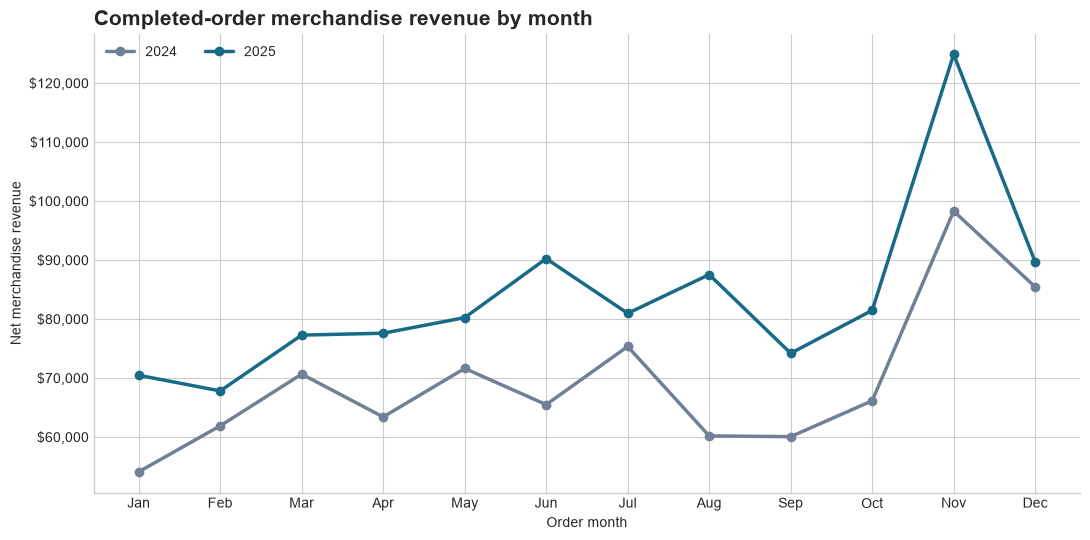

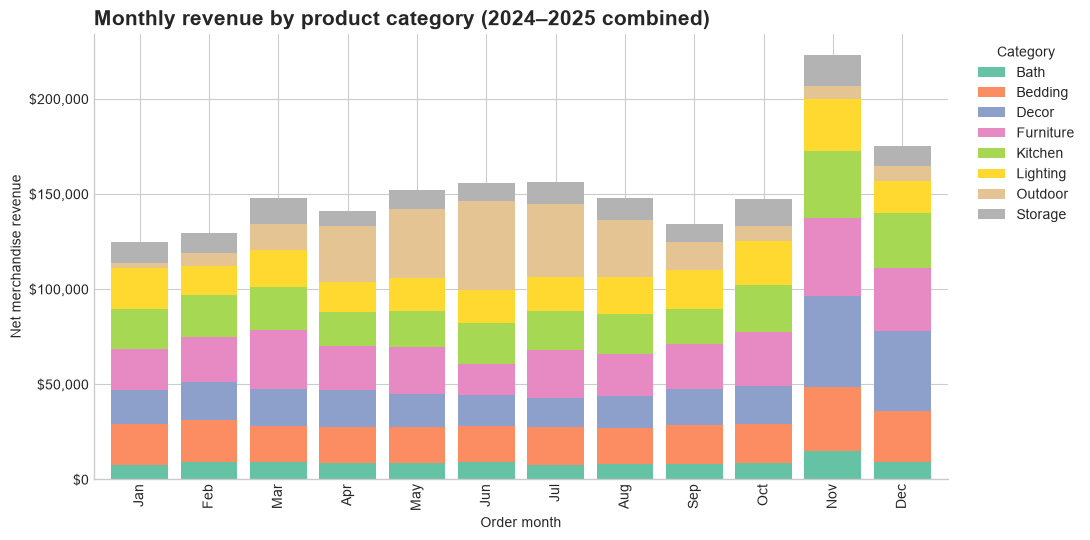

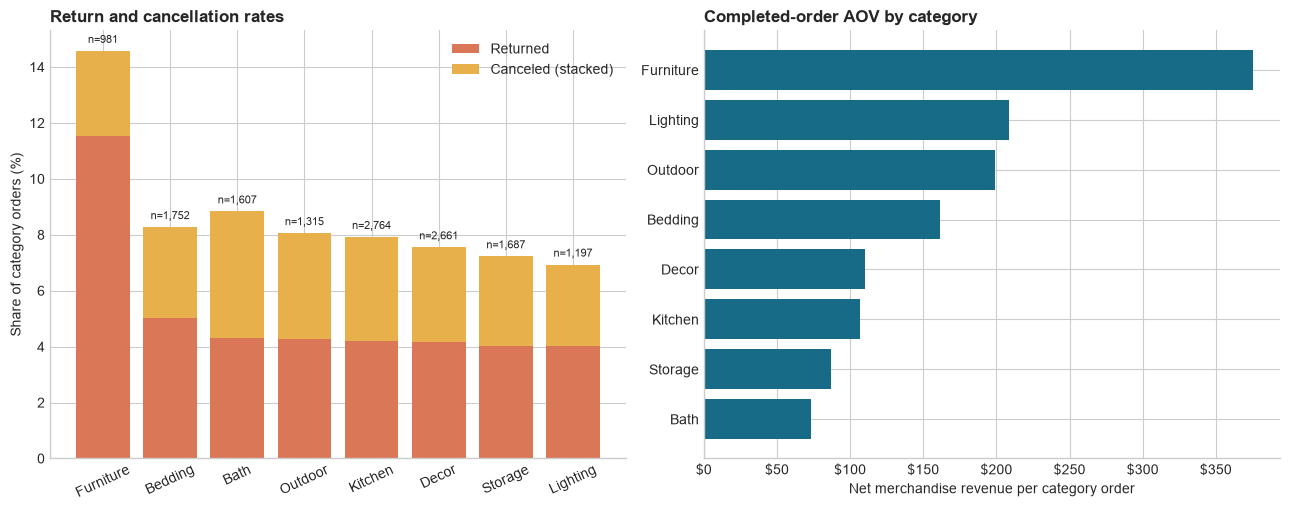

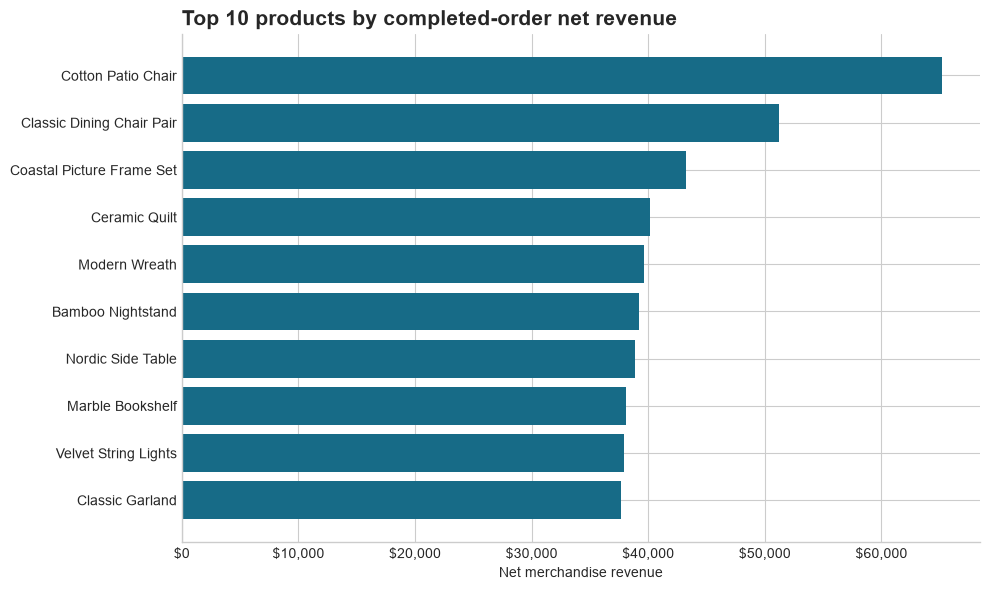

In [21]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.style.use("seaborn-v0_8-whitegrid")
brand_colors = {2024: "#718096", 2025: "#176B87"}
dollar_fmt = FuncFormatter(lambda value, _: f"${value:,.0f}")

# Chart 1: direct month-over-month year comparison.
fig, ax = plt.subplots(figsize=(11, 5.5))
month_labels = pd.date_range("2024-01-01", periods=12, freq="MS").strftime("%b")
ax.plot(month_labels, monthly_sales["2024"].values, marker="o", linewidth=2.5, color=brand_colors[2024], label="2024")
ax.plot(month_labels, monthly_sales["2025"].values, marker="o", linewidth=2.5, color=brand_colors[2025], label="2025")
ax.set_title("Completed-order merchandise revenue by month", loc="left", fontsize=15, weight="bold")
ax.set_ylabel("Net merchandise revenue")
ax.yaxis.set_major_formatter(dollar_fmt)
ax.set_xlabel("Order month")
ax.legend(frameon=False, ncol=2)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

# Chart 2: category revenue mix through the calendar year (two-year pooled values).
fig, ax = plt.subplots(figsize=(11, 5.5))
category_mix_plot = monthly_category.copy()
category_mix_plot.index = month_labels
category_mix_plot.plot(kind="bar", stacked=True, ax=ax, colormap="Set2", width=0.82)
ax.set_title("Monthly revenue by product category (2024–2025 combined)", loc="left", fontsize=15, weight="bold")
ax.set_ylabel("Net merchandise revenue")
ax.yaxis.set_major_formatter(dollar_fmt)
ax.set_xlabel("Order month")
ax.legend(title="Category", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

# Chart 3: category rates and order value, making volume visible via the count labels.
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
plot_categories = category_outcomes.sort_values("return_rate_pct", ascending=False)
labels = plot_categories.index.tolist()
axes[0].bar(labels, plot_categories["return_rate_pct"], color="#D97757", label="Returned")
axes[0].bar(labels, plot_categories["cancellation_rate_pct"], bottom=plot_categories["return_rate_pct"], color="#E8B04A", label="Canceled (stacked)")
axes[0].set_title("Return and cancellation rates", loc="left", weight="bold")
axes[0].set_ylabel("Share of category orders (%)")
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend(frameon=False)
for i, category in enumerate(labels):
    axes[0].text(i, plot_categories.loc[category, "return_rate_pct"] + plot_categories.loc[category, "cancellation_rate_pct"] + 0.2,
                 f"n={int(plot_categories.loc[category, 'orders_with_category']):,}", ha="center", va="bottom", fontsize=8)

plot_aov = category_outcomes.reindex(category_outcomes["category_aov"].sort_values().index)
axes[1].barh(plot_aov.index, plot_aov["category_aov"], color="#176B87")
axes[1].set_title("Completed-order AOV by category", loc="left", weight="bold")
axes[1].set_xlabel("Net merchandise revenue per category order")
axes[1].xaxis.set_major_formatter(dollar_fmt)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

# Chart 4: highest-revenue products.
fig, ax = plt.subplots(figsize=(10, 6))
top_plot = top_products_by_revenue.sort_values("net_revenue", ascending=True)
ax.barh(top_plot["product_name"], top_plot["net_revenue"], color="#176B87")
ax.set_title("Top 10 products by completed-order net revenue", loc="left", fontsize=15, weight="bold")
ax.set_xlabel("Net merchandise revenue")
ax.xaxis.set_major_formatter(dollar_fmt)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()


In [24]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

chart_dir = DATA_DIR.resolve().parent / "assets" / "charts"
chart_dir.mkdir(parents=True, exist_ok=True)
dollar_fmt = FuncFormatter(lambda value, _: f"${value:,.0f}")
month_labels = pd.date_range("2024-01-01", periods=12, freq="MS").strftime("%b")

# Save figures as standalone assets so the README can embed them.
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(month_labels, monthly_sales["2024"].values, marker="o", linewidth=2.5, color="#718096", label="2024")
ax.plot(month_labels, monthly_sales["2025"].values, marker="o", linewidth=2.5, color="#176B87", label="2025")
ax.set(title="Completed-order merchandise revenue by month", xlabel="Order month", ylabel="Net merchandise revenue")
ax.yaxis.set_major_formatter(dollar_fmt)
ax.legend(frameon=False, ncol=2)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(chart_dir / "monthly_revenue_comparison.png", dpi=160, bbox_inches="tight")
plt.close(fig)

fig, ax = plt.subplots(figsize=(11, 5.5))
category_mix = monthly_category.copy()
category_mix.index = month_labels
category_mix.plot(kind="bar", stacked=True, ax=ax, colormap="Set2", width=0.82)
ax.set(title="Monthly revenue by product category (2024–2025 combined)", xlabel="Order month", ylabel="Net merchandise revenue")
ax.yaxis.set_major_formatter(dollar_fmt)
ax.legend(title="Category", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(chart_dir / "monthly_category_mix.png", dpi=160, bbox_inches="tight")
plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
plot_categories = category_outcomes.sort_values("return_rate_pct", ascending=False)
labels = plot_categories.index.tolist()
axes[0].bar(labels, plot_categories["return_rate_pct"], color="#D97757", label="Returned")
axes[0].bar(labels, plot_categories["cancellation_rate_pct"], bottom=plot_categories["return_rate_pct"], color="#E8B04A", label="Canceled (stacked)")
axes[0].set(title="Return and cancellation rates", ylabel="Share of category orders (%)")
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend(frameon=False)
for i, category in enumerate(labels):
    total_rate = plot_categories.loc[category, "return_rate_pct"] + plot_categories.loc[category, "cancellation_rate_pct"]
    axes[0].text(i, total_rate + 0.2, f"n={int(plot_categories.loc[category, 'orders_with_category']):,}", ha="center", fontsize=8)
plot_aov = category_outcomes.sort_values("category_aov")
axes[1].barh(plot_aov.index, plot_aov["category_aov"], color="#176B87")
axes[1].set(title="Completed-order AOV by category", xlabel="Net merchandise revenue per category order")
axes[1].xaxis.set_major_formatter(dollar_fmt)
for axis in axes:
    axis.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(chart_dir / "category_returns_cancellations_aov.png", dpi=160, bbox_inches="tight")
plt.close(fig)

fig, ax = plt.subplots(figsize=(10, 6))
top_plot = top_products_by_revenue.sort_values("net_revenue", ascending=True)
ax.barh(top_plot["product_name"], top_plot["net_revenue"], color="#176B87")
ax.set(title="Top 10 products by completed-order net revenue", xlabel="Net merchandise revenue")
ax.xaxis.set_major_formatter(dollar_fmt)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(chart_dir / "top_products_by_revenue.png", dpi=160, bbox_inches="tight")
plt.close(fig)

print("Saved README chart images in:", chart_dir)


Saved README chart images in: D:\Data Analytics\Wayfare_E-commerce_Sales_Analytics\assets\charts


## 7. One-page decision summary

### Three key findings

The following findings are generated directly from the cleaned 2024–2025 tables above, so they stay in sync if the source exports are refreshed.

In [8]:
from IPython.display import Markdown, display

revenue_2024 = float(annual_sales.loc[2024, "revenue"]) if 2024 in annual_sales.index else 0.0
revenue_2025 = float(annual_sales.loc[2025, "revenue"]) if 2025 in annual_sales.index else 0.0
orders_2024 = int(annual_sales.loc[2024, "completed_orders"]) if 2024 in annual_sales.index else 0
orders_2025 = int(annual_sales.loc[2025, "completed_orders"]) if 2025 in annual_sales.index else 0
aov_2024 = float(annual_sales.loc[2024, "average_order_value"]) if 2024 in annual_sales.index else 0.0
aov_2025 = float(annual_sales.loc[2025, "average_order_value"]) if 2025 in annual_sales.index else 0.0
revenue_growth = (revenue_2025 / revenue_2024 - 1) * 100 if revenue_2024 else np.nan
orders_growth = (orders_2025 / orders_2024 - 1) * 100 if orders_2024 else np.nan
aov_growth = (aov_2025 / aov_2024 - 1) * 100 if aov_2024 else np.nan

leading_category = category_year_revenue.index[0]
leading_category_share = float(category_year_revenue.loc[leading_category, "share_of_sales_pct"])
leading_product = top_products_by_revenue.iloc[0]
peak_month = monthly_category.sum(axis=1).idxmax()
monthly_growth = monthly_sales["2025_vs_2024_pct"].dropna()
best_growth_month = monthly_growth.idxmax() if not monthly_growth.empty else "not available"
worst_growth_month = monthly_growth.idxmin() if not monthly_growth.empty else "not available"
category_outcomes["combined_return_cancel_rate_pct"] = category_outcomes["return_rate_pct"] + category_outcomes["cancellation_rate_pct"]
watch_category = category_outcomes["combined_return_cancel_rate_pct"].idxmax()
watch_category_stats = category_outcomes.loc[watch_category]

summary = f"""### Three key findings

1. **Growth was led by order volume:** completed-order merchandise revenue rose from **${revenue_2024:,.0f} in 2024** to **${revenue_2025:,.0f} in 2025** ({revenue_growth:+.1f}%, or ${revenue_2025 - revenue_2024:,.0f}). Included completed orders grew {orders_growth:+.1f}%, while AOV increased {aov_growth:+.1f}%, so the order-count gain was the larger driver.
2. **Furniture leads both sales and quality risk:** it contributed **{leading_category_share:.1f}%** of two-year revenue, with the highest category AOV (${category_outcomes.loc["Furniture", "category_aov"]:,.2f}) and the highest combined return/cancellation rate ({watch_category_stats['combined_return_cancel_rate_pct']:.2f}% across {watch_category_stats['orders_with_category']:,.0f} category orders). **{leading_product['product_name']}** was the top product by revenue (${leading_product['net_revenue']:,.0f}; {leading_product['units_sold']:,.0f} units).
3. **Sales are seasonal, but 2025 improved throughout the year:** November was the peak pooled month in both years, while monthly revenue was higher year over year in all 12 months. August had the strongest monthly growth ({monthly_growth.loc[best_growth_month]:+.1f}%) and December the weakest ({monthly_growth.loc[worst_growth_month]:+.1f}%).

### Two recommendations for next year's plan

1. **Reduce furniture returns before scaling its sales:** review return reasons, delivery damage, assembly/specification clarity, and product-level defects. Start with high-revenue furniture SKUs, then monitor return and cancellation rates with order counts and a finance-validated refund measure.
2. **Prepare inventory and fulfillment for November:** set capacity and campaign milestones ahead of the demonstrated peak, then allocate incremental marketing using the 2025 monthly growth evidence. Do not extrapolate a single peak month as a forecast; validate the pattern against another year and supply constraints.

**Data and metric caveat:** 38 repeated order records were removed; 199 order-item rows had missing/invalid required measures, affecting 197 orders. To avoid partial order revenue, 174 completed orders were excluded from revenue and AOV. If missing prices are not random, the reported growth and category mix may be biased. Revenue is discounted merchandise value for completed orders, not finance-reconciled net revenue after refunds, shipping, or tax; reconcile before formal financial reporting.
"""
display(Markdown(summary))


### Three key findings

1. **Growth was led by order volume:** completed-order merchandise revenue rose from **$831,807 in 2024** to **$1,001,536 in 2025** (+20.4%, or $169,729). Included completed orders grew +18.1%, while AOV increased +2.0%, so the order-count gain was the larger driver.
2. **Furniture leads both sales and quality risk:** it contributed **17.1%** of two-year revenue, with the highest category AOV ($375.06) and the highest combined return/cancellation rate (14.58% across 981 category orders). **Cotton Patio Chair** was the top product by revenue ($65,190; 138 units).
3. **Sales are seasonal, but 2025 improved throughout the year:** November was the peak pooled month in both years, while monthly revenue was higher year over year in all 12 months. August had the strongest monthly growth (+45.5%) and December the weakest (+5.0%).

### Two recommendations for next year's plan

1. **Reduce furniture returns before scaling its sales:** review return reasons, delivery damage, assembly/specification clarity, and product-level defects. Start with high-revenue furniture SKUs, then monitor return and cancellation rates with order counts and a finance-validated refund measure.
2. **Prepare inventory and fulfillment for November:** set capacity and campaign milestones ahead of the demonstrated peak, then allocate incremental marketing using the 2025 monthly growth evidence. Do not extrapolate a single peak month as a forecast; validate the pattern against another year and supply constraints.

**Data and metric caveat:** 38 repeated order records were removed; 199 order-item rows had missing/invalid required measures, affecting 197 orders. To avoid partial order revenue, 174 completed orders were excluded from revenue and AOV. If missing prices are not random, the reported growth and category mix may be biased. Revenue is discounted merchandise value for completed orders, not finance-reconciled net revenue after refunds, shipping, or tax; reconcile before formal financial reporting.
